Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use an MCMC parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

## Path to PE result file

In [50]:
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection.dat"

## Post-process the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [51]:
from gw_eccentricity.posterior.post_process_for_bilby import PostProcessForBilby

## create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [52]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [53]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# Posteriors

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [65]:
egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file)

18:20 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


# Looking at the original posteriors

In [66]:
egwBilby.get_posterior()

18:20 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


,H1_log_likelihood,H1_matched_filter_snr,H1_optimal_snr,L1_log_likelihood,L1_matched_filter_snr,L1_optimal_snr,L1_time,V1_log_likelihood,V1_matched_filter_snr,V1_optimal_snr,...,spin_2x,spin_2y,spin_2z,symmetric_mass_ratio,theta_jn,tilt_1,tilt_2,total_mass,total_mass_source,waveform_approximant
0,623.536988,35.393036- 1.832653j,36.320440,832.897895,40.886870+ 0.337570j,41.362264,2.022867,79.990989,12.783959+ 0.292588j,13.283787,...,0,0,0.840667,0.241917,0.254826,0.0,0.0,117.996238,87.927810,TEOBResumSDALI
1,623.737121,35.413042- 0.219257j,36.072400,834.313813,40.934172+ 0.893366j,40.930566,2.020499,78.126882,12.680335- 1.206002j,12.763677,...,0,0,0.884071,0.247294,0.799544,0.0,0.0,117.215195,91.807840,TEOBResumSDALI
2,625.263228,35.442456- 1.632387j,35.903969,829.859150,40.812956- 0.412181j,40.807886,2.023034,82.320345,12.970347+ 0.254119j,13.072128,...,0,0,0.756452,0.239020,0.189148,0.0,0.0,116.939708,87.103236,TEOBResumSDALI
3,623.660924,35.395494- 2.728341j,34.966475,833.187739,40.892780+ 2.002818j,40.065281,2.020089,81.065828,12.864432+ 0.454741j,12.946800,...,0,0,0.868357,0.247583,0.161180,0.0,0.0,117.422422,86.382175,TEOBResumSDALI
4,627.470438,35.506280+ 0.409910j,35.208147,830.505277,40.830341- 0.528652j,39.797103,2.020817,79.868891,12.782441+ 0.623043j,12.668456,...,0,0,0.812520,0.239390,0.230434,0.0,0.0,115.367024,86.073716,TEOBResumSDALI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12723,626.550917,35.499546+ 0.073499j,36.098698,845.009001,41.201355+ 0.036744j,40.760186,2.020851,82.309320,13.023293- 0.098106j,13.410467,...,0,0,0.885188,0.249987,0.951851,0.0,0.0,118.877416,95.101984,TEOBResumSDALI
12724,626.300630,35.496080- 0.830289j,35.969990,844.760389,41.198333+ 0.404540j,40.711227,2.020917,82.643707,13.059309- 0.070462j,13.374895,...,0,0,0.881033,0.249998,1.021669,0.0,0.0,118.442282,95.681426,TEOBResumSDALI
12725,626.957177,35.513985- 0.266306j,37.514769,844.633748,41.194731+ 0.495985j,42.412076,2.020852,82.200797,13.022836- 0.172487j,13.950999,...,0,0,0.888504,0.249980,1.004888,0.0,0.0,118.374764,96.129032,TEOBResumSDALI
12726,627.806113,35.532200+ 0.171292j,37.527899,844.150416,41.177941+ 1.132581j,42.491474,2.021137,82.267627,13.011608+ 0.770148j,14.006202,...,0,0,0.890064,0.249990,0.893409,0.0,0.0,118.771925,94.895787,TEOBResumSDALI


(<Figure size 600x400 with 1 Axes>, <Axes: >)

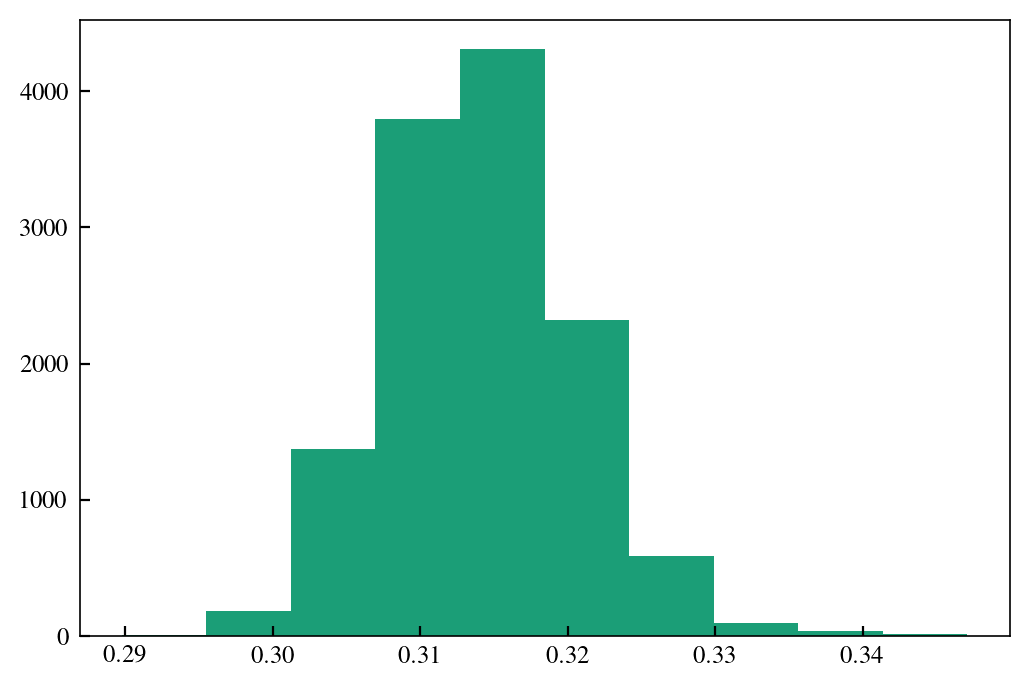

In [67]:
egwBilby.plot_eccentricity_posterior(**{"bins": 10})

In [97]:
egwBilby.get_injection()

,mass_1,mass_2,dec,ra,theta_jn,psi,phase,spin_1z,spin_2z,a_1,a_2,luminosity_distance,geocent_time,eccentricity,minimum_frequency,mean_per_ano
0,60.0,60.0,-0.5,3.38,0.7854,0.7854,0.7854,0.9,0.9,0.9,0.9,1500.0,0.0,0.3,10.0,0


In [74]:
data_dict = egwBilby.get_injection_data_dict()

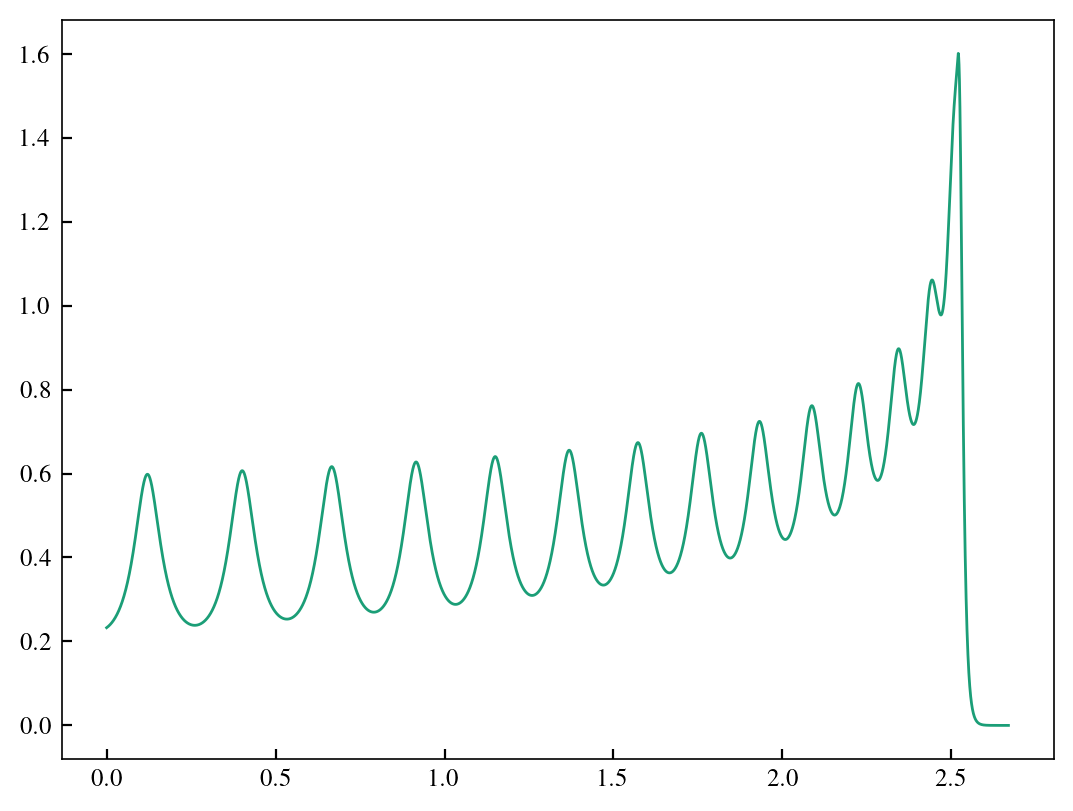

In [75]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

# Getting the best fref to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [76]:
# some settings to use
method = "AmplitudeFits"
gw_eccentricity_kwargs = {"extra_kwargs": {"omega_gw_extrema_interpolation_method": "spline"}}
samples = np.arange(0, 200)
n_jobs = 6

We can check the range of frequencies where eccentricity and mean anomaly could be measured using the following method

In [77]:
egwBilby.get_fref_bounds_for_sample(sample_index=87, method=method, gw_eccentricity_kwargs=gw_eccentricity_kwargs)

{'sample_index': 87,
 'method': 'AmplitudeFits',
 'status': 'success',
 'fref_min': np.float64(8.560053100460085),
 'fref_max': np.float64(30.588036569006952)}

In [78]:
egwBilby.get_fref_bounds(samples=samples,
                         method=method,
                         n_jobs=n_jobs,
                         gw_eccentricity_kwargs=gw_eccentricity_kwargs
                        )

Getting fref bounds:  54%|██████████████████████████████████████████████████████████████████████████████▎                                                                  | 108/200 [00:08<00:04, 19.93it/s]/opt/miniconda3/envs/gwecc/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Getting fref bounds: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:16<00:00, 12.14it/s]


{'fref_bounds': (np.float64(8.654797152034892), np.float64(30.01172509207587)),
 'success_percentage': 100.0,
 'failed_cases': []}

# Post-processing

We can measure eccentricity and mean anomaly for any sample using the following method

In [79]:
fref = 10
egwBilby.measure_eccentricity_for_sample(
    sample_index=5223,
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)

{'sample_index': 5223,
 'method': 'AmplitudeFits',
 'fref': 10,
 'status': 'success',
 'eccentricity': np.float64(0.3106663249240249),
 'mean_anomaly': np.float64(2.307720566278457)}

We can postprocess a subset of the smaples or all the samples using the following method

In [80]:
import time

In [81]:
fref = 10
t_start = time.perf_counter()
egwBilby.post_process(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Post-processing samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:09<00:00, 20.03it/s]


In [82]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 10.788724332998754 seconds for 200 samples on 6 cores.


View the results

In [83]:
egwBilby.post_process_result[:5]

[{'sample_index': np.int64(0),
  'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.35274067986995084),
  'mean_anomaly': np.float64(4.6116213185060815)},
 {'sample_index': np.int64(1),
  'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.3493114151362695),
  'mean_anomaly': np.float64(4.808148824239943)},
 {'sample_index': np.int64(2),
  'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.35903151990418425),
  'mean_anomaly': np.float64(4.448870874454748)},
 {'sample_index': np.int64(3),
  'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.3300606690705985),
  'mean_anomaly': np.float64(2.6041981818533344)},
 {'sample_index': np.int64(4),
  'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.35618468097422373),
  'mean_anomaly': np.float64(2.9594004045532554)}]

In [96]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
    # debug=True
)

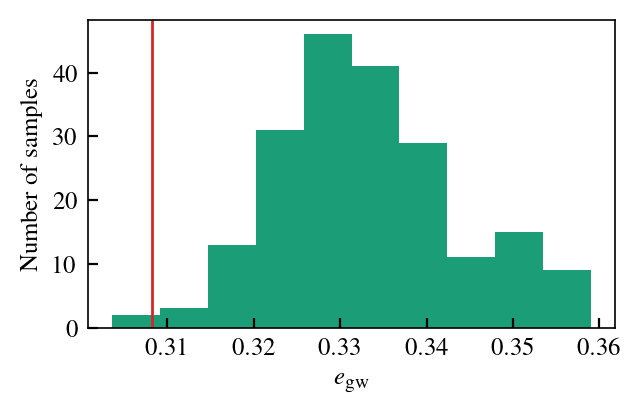

In [95]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

## Get a summary of the post-process, like how many cases were successfully post-processed

In [34]:
egwBilby.post_process_summary()

{'total_samples': 200,
 'success_percentage': 100.0,
 'fref': 10,
 'method': 'AmplitudeFits',
 'eccentricity': [np.float64(0.3529395566648157),
  np.float64(0.3492021887039125),
  np.float64(0.35937019871418663),
  np.float64(0.33011531469694644),
  np.float64(0.35615850968980156),
  np.float64(0.3576092755000363),
  np.float64(0.35801062337207723),
  np.float64(0.3519107695617196),
  np.float64(0.35334236253497486),
  np.float64(0.3553934122209106),
  np.float64(0.33323175768846425),
  np.float64(0.33585321657672873),
  np.float64(0.3517464778540621),
  np.float64(0.3220810437991075),
  np.float64(0.3409096737607772),
  np.float64(0.3570721170948964),
  np.float64(0.3532252197909259),
  np.float64(0.34691637466726843),
  np.float64(0.3364396096490363),
  np.float64(0.3327021992774687),
  np.float64(0.3256775088253484),
  np.float64(0.3165222007686075),
  np.float64(0.335741917165034),
  np.float64(0.33039574105802594),
  np.float64(0.3425878580569448),
  np.float64(0.35086331538823545